In [2]:
#import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import sklearn 
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import recall_score


In [3]:
#read and load the data
data=pd.read_csv("new liver.csv")
print (f"Total number of samples: {data.shape[0]}. Total number of features in each sample: {data.shape[1]} .")

#get the first five data 
data.head()

Total number of samples: 583. Total number of features in each sample: 11 .


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [4]:
#to get the tail info of the dataset
data.tail()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


In [5]:
# help to know if there are missing data or not
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [6]:
data.describe()


,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [7]:
data.shape

(583, 11)

In [8]:
#commence data preprocessing

#check to see if there are duplicates
''' Duplicates are removed as it's most likely these entries has been inputed twice.'''
data_duplicate = data[data.duplicated(keep = False)] 
# keep = False gives you all rows with duplicate entries
data_duplicate

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
18,40,Female,0.9,0.3,293,232,245,6.8,3.1,0.80,1
19,40,Female,0.9,0.3,293,232,245,6.8,3.1,0.80,1
25,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.10,1
26,34,Male,4.1,2.0,289,875,731,5.0,2.7,1.10,1
33,38,Female,2.6,1.2,410,59,57,5.6,3.0,0.80,2
34,38,Female,2.6,1.2,410,59,57,5.6,3.0,0.80,2
54,42,Male,8.9,4.5,272,31,61,5.8,2.0,0.50,1
55,42,Male,8.9,4.5,272,31,61,5.8,2.0,0.50,1
61,58,Male,1.0,0.5,158,37,43,7.2,3.6,1.00,1
62,58,Male,1.0,0.5,158,37,43,7.2,3.6,1.00,1


In [9]:
data = data[~data.duplicated(subset = None, keep = 'first')]
# Here, keep = 'first' ensures that only the first row is taken into the final dataset.
# The '~' sign tells pandas to keep all values except the 13 duplicate values
data.shape

(570, 11)

In [10]:
#checking if there are any NULL values in our Dataset
data.isnull().values.any()

True

In [11]:
#removing null values
# display number of null values by column# display number of null values by column
print(data.isnull().sum()) 

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64


In [12]:
# We can see that the column 'Albumin_and_Globulin_Ratio' has 4 missing values
# One way to deal with them can be to just directly remove these 4 values
print ("length before removing NaN values:%d"%len(data))
data_2 = data[pd.notnull(data['Albumin_and_Globulin_Ratio'])]
print ("length after removing NaN values:%d"%len(data_2))


length before removing NaN values:570
length after removing NaN values:566


In [14]:
new_data=data.dropna(axis = 0, how ='any')


In [15]:
new_data.isnull().values.any()

False

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 570 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         570 non-null    int64  
 1   Gender                      570 non-null    object 
 2   Total_Bilirubin             570 non-null    float64
 3   Direct_Bilirubin            570 non-null    float64
 4   Alkaline_Phosphotase        570 non-null    int64  
 5   Alamine_Aminotransferase    570 non-null    int64  
 6   Aspartate_Aminotransferase  570 non-null    int64  
 7   Total_Protiens              570 non-null    float64
 8   Albumin                     570 non-null    float64
 9   Albumin_and_Globulin_Ratio  566 non-null    float64
 10  Dataset                     570 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 53.4+ KB


In [17]:
'''
The Albumin-Globulin Ratio feature has four missing values, as seen above. Here, we are dropping those particular rows which have missing data. We could, in fact, fill those place with values of our own, using options like:

A constant value that has meaning within the domain, such as 0, distinct from all other values.
A value from another randomly selected record, or the immediately next or previous record.
A mean, median or mode value for the column.
A value estimated by another predictive model.
But here, since a very small fraction of values are missing, we choose to drop those rows.
'''
#Transform our data
from sklearn import preprocessing

le = preprocessing.LabelEncoder()
le.fit(['Male','Female'])
data.loc[:,'Gender'] = le.transform(data['Gender'])

#Remove rows with missing values
data = data.dropna(how = 'any', axis = 0)

#Also transform Selector variable into usual conventions followed
data['Dataset'] = data['Dataset'].map({2:0, 1:1})

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [18]:
#Overview of data
data.head()


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [19]:
#features characteristics to determine if feature scaling is necessary
data.describe()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000
mean,44.886926,0.756184,3.338869,1.505830,292.567138,80.143110,109.892226,6.494876,3.145583,0.948004,0.713781
std,16.274893,0.429763,6.286728,2.841485,245.936559,182.044881,291.841897,1.087512,0.795745,0.319635,0.452393
min,4.000000,0.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000
25%,33.000000,1.000000,0.800000,0.200000,176.000000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000
50%,45.000000,1.000000,1.000000,0.300000,208.000000,35.000000,41.000000,6.600000,3.100000,0.950000,1.000000
75%,58.000000,1.000000,2.600000,1.300000,298.000000,60.750000,87.000000,7.200000,3.800000,1.100000,1.000000
max,90.000000,1.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000


In [20]:
#split the data into test and train samples
X_train, X_test, y_train, y_test = train_test_split(data, data['Dataset'],test_size=0.2, random_state = 0)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
#Exploratory Data Analysis

#Determining the healthy-affected split
print("Positive records:", data['Dataset'].value_counts().iloc[0])
print("Negative records:", data['Dataset'].value_counts().iloc[1])


Positive records: 404
Negative records: 162


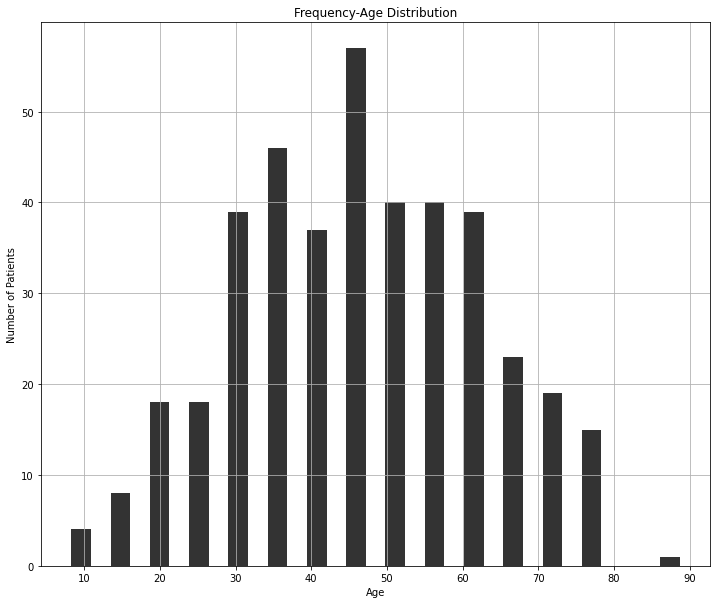

In [22]:
#The above output confirms that we have 414 positive and 165 negative records. This indicates that this is a highly unbalanced dataset.

#Determine statistics based on age
plt.figure(figsize=(12, 10))
plt.hist(data[data['Dataset'] == 1]['Age'], bins = 16, align = 'mid', rwidth = 0.5, color = 'black', alpha = 0.8)
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.title('Frequency-Age Distribution')
plt.grid(True)
plt.savefig('fig1')
plt.show()

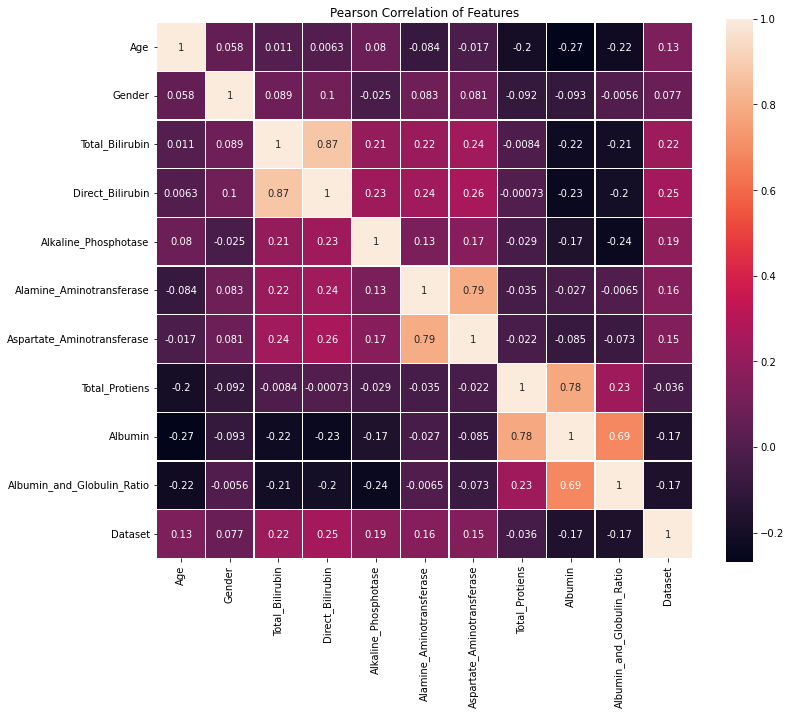

In [23]:
#Looking at the age vs. frequency graph, we can observe that middle-aged people are the worst affected. Even elderly people are also suffering from liver ailments,
#as seen by the bar sizes at ages 60-80.

#correlation-matrix
plt.subplots(figsize=(12, 10))
plt.title('Pearson Correlation of Features')
# Draw the heatmap using seaborn
sns.heatmap(data.corr(),linewidths=0.25, vmax=1.0, square=True,annot=True)
plt.savefig('fig2')
plt.show()

In [43]:
'''
The correlation matrix gives us the relationship between two features. As seen above, the following pairs of features seem to be very closely related as indicated by their high correlation coefficients:

1.Total Bilirubin and Direct Bilirubin(0.87)
2.Sgpt Alamine Aminotransferase and Sgot Aspartate Aminotransferase(0.79)
3.Albumin and Total Proteins(0.78)
4.Albumin and Albumin-Globulin Ratio(0.69)
'''

'''
#Using Classification Algorithms
Let us now evaluate the performance of various classifiers on this dataset. 
For the sake of understanding as to how feature scaling affects classifier performance, 
we will train models using both scaled and unscaled data. 
Since we are interested in capturing records of people who have been tested positive,
we will base our classifier evaluation metric on precision and recall instead of accuracy.
We could also use F1 score, since it takes into account both precision and recall.
'''

#Logistic Regression: Using normal data
logreg = LogisticRegression(C = 0.1).fit(X_train, y_train)
print("Logistic Regression Classifier on unscaled test data:")
print("Accuracy:", logreg.score(X_test, y_test))
print("Precision:", precision_score(y_test, logreg.predict(X_test)))
print("Recall:", recall_score(y_test, logreg.predict(X_test)))
print("F-1 score:", f1_score(y_test, logreg.predict(X_test)))

Logistic Regression Classifier on unscaled test data:
Accuracy: 0.9824561403508771
Precision: 0.9759036144578314
Recall: 1.0
F-1 score: 0.9878048780487805


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,


In [46]:
#Using feature-scaled data
logreg_scaled = LogisticRegression(C = 0.01).fit(X_train_scaled, y_train)
print("Logistic Regression Classifier on scaled test data:")
print("Accuracy:", logreg_scaled.score(X_test_scaled, y_test))
print("Precision:", precision_score(y_test, logreg_scaled.predict(X_test_scaled)))
print("Recall:", recall_score(y_test, logreg_scaled.predict(X_test_scaled)))
print("F-1 score:", f1_score(y_test, logreg_scaled.predict(X_test_scaled)))


Logistic Regression Classifier on scaled test data:
Accuracy: 0.7105263157894737
Precision: 0.7105263157894737
Recall: 1.0
F-1 score: 0.8307692307692308


In [41]:
'''
Well! The performance has definitely improved by feature scaling, though not drastically, 
as there was already very little scope of improvement. 
Let us look at other classifiers and analyse how they react to scaling.
'''

#SVM Classifier with RBF kernel: Using normal data
svc_clf = SVC(C = 0.01, kernel = 'rbf').fit(X_train, y_train)
print("SVM Classifier on unscaled test data:")
print("Accuracy:", svc_clf.score(X_test, y_test))
print("Precision:", precision_score(y_test, svc_clf.predict(X_test)))
print("Recall:", recall_score(y_test, svc_clf.predict(X_test)))
print("F-1 score:", f1_score(y_test, svc_clf.predict(X_test)))


SVM Classifier on unscaled test data:
Accuracy: 0.7105263157894737
Precision: 0.7105263157894737
Recall: 1.0
F-1 score: 0.8307692307692308


In [49]:
#Using scaled data
svc_clf_scaled = SVC(C = 0.01, kernel = 'rbf').fit(X_train_scaled, y_train)
print("SVM Classifier on scaled test data:")
print("Accuracy:", svc_clf_scaled.score(X_test_scaled, y_test))
print("Precision:", precision_score(y_test, svc_clf_scaled.predict(X_test_scaled)))
print("Recall:", recall_score(y_test, svc_clf_scaled.predict(X_test_scaled)))
print("F-1 score:", f1_score(y_test, svc_clf_scaled.predict(X_test_scaled)))


SVM Classifier on scaled test data:
Accuracy: 0.7105263157894737
Precision: 0.7105263157894737
Recall: 1.0
F-1 score: 0.8307692307692308


In [55]:
#Random Forest Classifier: using normal data
rfc = RandomForestClassifier(n_estimators = 2)
rfc.fit(X_train, y_train)
print("SVM Classifier on unscaled test data:")
print("Accuracy:", rfc.score(X_test, y_test))
print("Precision:", precision_score(y_test, rfc.predict(X_test)))
print("Recall:", recall_score(y_test, rfc.predict(X_test)))
print("F-1 score:", f1_score(y_test, rfc.predict(X_test)))

SVM Classifier on unscaled test data:
Accuracy: 0.9912280701754386
Precision: 1.0
Recall: 0.9876543209876543
F-1 score: 0.9937888198757764


In [56]:
#using scaled data
rfc_scaled = RandomForestClassifier(n_estimators = 2)
rfc_scaled.fit(X_train_scaled, y_train)
print("Random Forest Classifier on scaled test data:")
print("Accuracy:", rfc_scaled.score(X_test_scaled, y_test))
print("Precision:", precision_score(y_test, rfc_scaled.predict(X_test_scaled)))
print("Recall:", recall_score(y_test, rfc_scaled.predict(X_test_scaled)))
print("F-1 score:", f1_score(y_test, rfc_scaled.predict(X_test_scaled)))

Random Forest Classifier on scaled test data:
Accuracy: 0.9210526315789473
Precision: 1.0
Recall: 0.8888888888888888
F-1 score: 0.9411764705882353


In [68]:
#LGBM Classifier: using normal data
from lightgbm import LGBMClassifier

bgm = LGBMClassifier(learning_rate=0.001)
bgm.fit(X_train, y_train)
print("LGBM Classifier on unscaled test data:")
print("Accuracy:", bgm.score(X_test, y_test))
print("Precision:", precision_score(y_test, bgm.predict(X_test)))
print("Recall:", recall_score(y_test, bgm.predict(X_test)))
print("F-1 score:", f1_score(y_test, bgm.predict(X_test)))

LGBM Classifier on unscaled test data:
Accuracy: 0.7105263157894737
Precision: 0.7105263157894737
Recall: 1.0
F-1 score: 0.8307692307692308


In [78]:
from xgboost import XGBClassifier
from sklearn import metrics

Xgm = XGBClassifier(learning_rate =0.0001,random_state=42)
Xgm.fit(X_train, y_train)
print("XGB Classifier on unscaled test data:")
print("Accuracy:", Xgm.score(X_test, y_test))
print("Precision:", precision_score(y_test, Xgm.predict(X_test)))
print("Recall:", recall_score(y_test, Xgm.predict(X_test)))
print("F-1 score:", f1_score(y_test, Xgm.predict(X_test)))

XGB Classifier on unscaled test data:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F-1 score: 1.0
